# EDA для TMDB Movies Dataset

**Бизнес-контекст:** Сайт для поиска фильмов "TMDB" хочет повысить конверсию своего каталога.  
Гипотеза: постер, по которому точно понятен жанр, формирует правильные ожидания у зрителя, а значит зритель не будет разочарован и поставит более высокую оценку.  

**Две ML-задачи:**
- **Табличная (FCN):** предсказание рейтинга фильма по метаданным
- **CV (CNN/ViT):** оценка соответствия постера жанру и выявление фильмов с непонятными постерами

**Цель этого ноутбука:** понять данные, проверить базовые гипотезы, подготовить данные к обучению моделей.

## 0. Импорты

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

## 1. Загрузка данных

In [140]:
df = pd.read_csv("../data/raw/TMDB_movie_dataset_v11.csv")
df.head(3)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."


In [141]:
df.shape

(1437247, 24)

Получается 1437247 строк и 24 колонки

Далее посмотрим на типы данных в датасете и наличие пропусков

In [142]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

homepage                1289813
tagline                 1236678
keywords                1083587
backdrop_path           1081869
production_companies     827581
imdb_id                  765226
production_countries     698696
spoken_languages         671204
genres                   634538
poster_path              513873
overview                 331244
release_date             324313
title                        19
original_title               19
dtype: int64

Это пропуски в абсолютных числах, далее выведем в процентах для наглядности

In [143]:
missing_count = missing[missing > 0].sort_values(ascending=False)
missing_count / 1437247 * 100

homepage                89.741916
tagline                 86.044918
keywords                75.393234
backdrop_path           75.273700
production_companies    57.580986
imdb_id                 53.242484
production_countries    48.613495
spoken_languages        46.700671
genres                  44.149544
poster_path             35.753980
overview                23.047117
release_date            22.564876
title                    0.001322
original_title           0.001322
dtype: float64

Итак, по типам и данных и пропускам какие выводы можно сделать. Для нас критически важны поля title и original_title, и в них всего по 19 пропусков. Просто шум по сути. vote_average в таблицу вообще не попал, а значит, что пропусков в нем нет пропусков.

Для нашей первой бизнес-задачи по предсказанию рейтингов фильмов по их метаданным важны сами метаданные. И с некоторыми из них есть проблемы. В release_date и genres 22.6 и 44.1 процентов пропусков соответственно. Это значит, что в случае работы с жанрами нам придется либо вырезать почти половину фильмов, либо придумать какую-то хитрую обработку для них. Примерно такая же ситуация и с production_companies и production_countries. В keywords, tagline и homepage пропусков вообще столько, что проще их сразу же удалить.

Для второй бизнес-задачи по выявлению жанра по постеру, ее ключевые поля poster_path пропущены у 35.8% и 44.1% строк, что в принципе норм и работу нам не рушит

## 2. Предобработка: извлечение жанров

Проверим, в каком формате у нас в таблице хранятся жанры

In [144]:
df["genres"].info

<bound method Series.info of 0                   Action, Science Fiction, Adventure
1                    Adventure, Drama, Science Fiction
2                       Drama, Action, Crime, Thriller
3          Action, Adventure, Fantasy, Science Fiction
4                   Science Fiction, Action, Adventure
                              ...                     
1437242                                            NaN
1437243                                          Drama
1437244                                          Drama
1437245                          Crime, Drama, Romance
1437246                                    Documentary
Name: genres, Length: 1437247, dtype: object>

Обычные строки текста, гуд, надо превратить их в список строк. Идея в том, что мы выделим в каждом фильме основной жанр, чтобы упростить себе жизнь в дальнейшем. Тем более, основной жанр - это именно то, на что ориентируется зритель

In [145]:
df['genres_list'] = df['genres'].fillna('').str.split(', ')

mask = df['genres'].isna() | (df['genres'] == '')
df.loc[mask, 'genres_list'] = pd.Series([[]] * mask.sum(), index=df.index[mask])

df['primary_genre'] = df['genres_list'].str[0]
df['n_genres'] = df['genres_list'].str.len()

df['primary_genre'].notna().sum()

np.int64(802709)

Вот столько у нас получилось фильмов, у которых указан основной жанр.

In [146]:
df['primary_genre'].isna().sum()

np.int64(634538)

А это без основного жанра

## 3. Целевая переменная: рейтинг

In [147]:
df_clean = df[
    (df['vote_count'] >= 50) &
    (df['vote_average'] > 0) &
    df['vote_average'].notna() &
    df['vote_count'].notna() &
    df['primary_genre'].notna() &
    df['poster_path'].notna()
]

len(df_clean)

27943

После фильтрации, в новой очищенной таблице осталось 27943 фильма. Фильтрация следующая: количество оценок не менее 50, чтобы каждый голос не имел сильно большой вес, так как если отзывов мало, то один отличный или откровенно негативный отзыв уже ощутимо повлияет на среднюю оценку фильма, плюс просто отсеиваем ноунеймов. Средняя оценка просто должна быть и быть больше нуля. Точно так же, как и поля с оценками, жанром и ссылкой на постер просто должны быть.

In [148]:
df_clean['vote_average'].describe()

count    27943.000000
mean         6.408971
std          0.881343
min          1.840000
25%          5.858000
50%          6.473000
75%          7.024000
max          9.980000
Name: vote_average, dtype: float64

Медиананная оценка - 6,47. 6,5 если округлять.

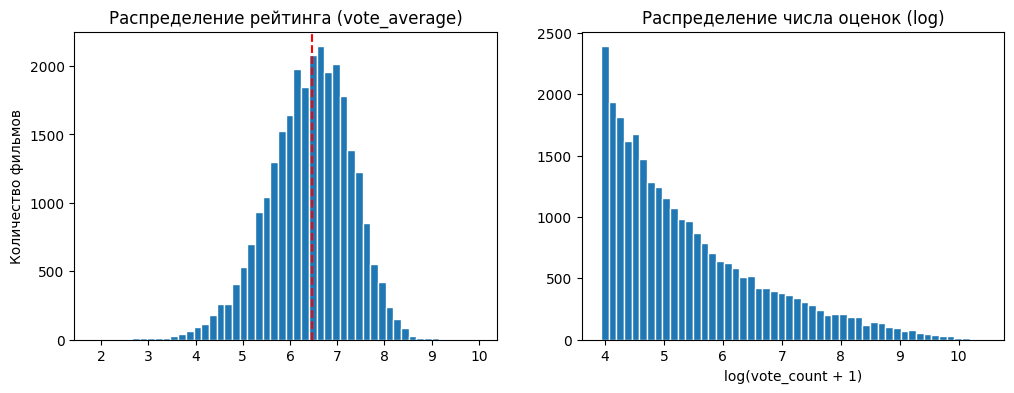

In [149]:
median_rating = df_clean['vote_average'].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['vote_average'], bins=50, edgecolor='white')
axes[0].axvline(median_rating, linestyle='--', color="red")
axes[0].set_title('Распределение рейтинга (vote_average)')
axes[0].set_ylabel('Количество фильмов')

axes[1].hist(np.log1p(df_clean['vote_count']), bins=50, edgecolor='white')
axes[1].set_title('Распределение числа оценок (log)')
axes[1].set_xlabel('log(vote_count + 1)')

plt.savefig('../data/processed/eda_rating_distribution.png')
plt.show()

Распределение рейтинга близко к нормальному. Медиана составляет 6,5, а стандартное отклонение - 0,88. Это означает, что оценки большинства фильмов сконцентрированы в диапазоне 5,5-7,5, а экстремальные значения (ниже 4 и выше 8,5) встречаются редко. Это хорошо для регрессии, потому что целевая переменная не потребует преобразования.

Распределение числа оценок сильно скошено вправо даже после логарифмирования. Большинство фильмов имеют 50-200 оценок, а высокая популярность, где голосов тысячи встречается редко. Распределение похоже на экспоненциальное. Вывод такой, что судить о средней оценке фильма можно только в привязке к количеству оценок. Собственно поэтому мы и отсекли фильмы, где оценок менее 50. И поэтому правый график начинается с 4, а не с 0.

Хоть регрессия это и хорошо, но надо прикинуть, что будет, если в табличной задаче применять классификаци. И в первую очередь надо понять, что для нас будет значить хороший фильм, а что плохой. За хороший фильм возьмем топ 30% рейтинга

In [150]:
threshold = df_clean['vote_average'].quantile(0.70)
df_clean['is_high_rated'] = (df_clean['vote_average'] >= threshold).astype(int)

threshold

/var/folders/mf/gpk354fs7md1m_w2r26tz7400000gn/T/ipykernel_21025/2757165551.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_high_rated'] = (df_clean['vote_average'] >= threshold).astype(int)


np.float64(6.903)

С порога 6.9 начинается высокий рейтинг

P.S. Дописываю после написания раздела по табличным данным.

В ходе EDA оставались сомнения, что предсказывать - среднюю оценку фильма или просто хороший он или плохой. Но с точки зрения полезности для бизнеса, в итоге было принято решение предсказывать именно саму оценку.

## 4. Анализ жанров

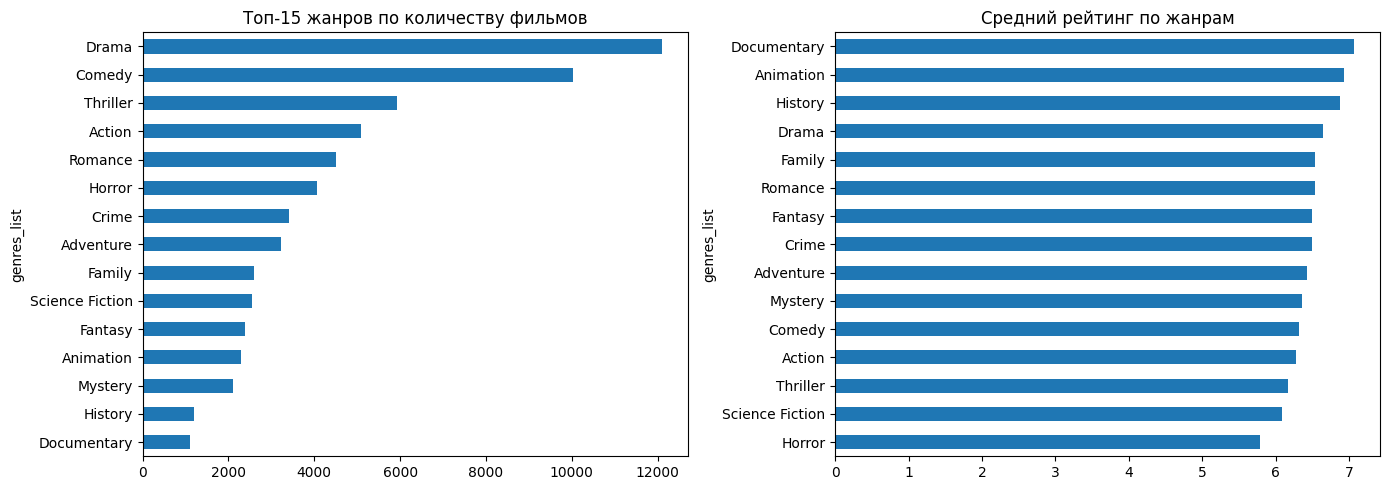

In [151]:
genres = df_clean.explode('genres_list')

genre_counts = genres['genres_list'].value_counts()
top_genres = genre_counts.head(15).index

genre_ratings = (
    genres[genres['genres_list'].isin(top_genres)]
    .groupby('genres_list')['vote_average']
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_counts.head(15).plot(kind='barh', ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title('Топ-15 жанров по количеству фильмов')

genre_ratings.plot(kind='barh', ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title('Средний рейтинг по жанрам')

plt.tight_layout()
plt.savefig('../data/processed/eda_genre_analysis.png')
plt.show()

График по топ-15 жанрам по количеству фильмов показывает, что драмы и комедии гораздо распространеннее остальных жанров. Вместе они составляют почти половину всех фильмов в датасете. Значит в задаче по табличным данным жанр как признак будет сильно смещен в сторону этих двух категорий.

График по среднему рейтингу по жанрам дает интересную картину. Оказывается, что самые популярные жанры вообще не самые высоко оцениваемые. Документальные, анимационные и исторические занимают топ-3 по среднему рейтингу, при этом они в хвосте по количеству фильмов. А хорроры - самый низко оцениваемый жанр, несмотря на приличный объём. Драмы и комедии, которые доминируют количественно, держатся чуть выше медианы.

## 5. Анализ числовых признаков

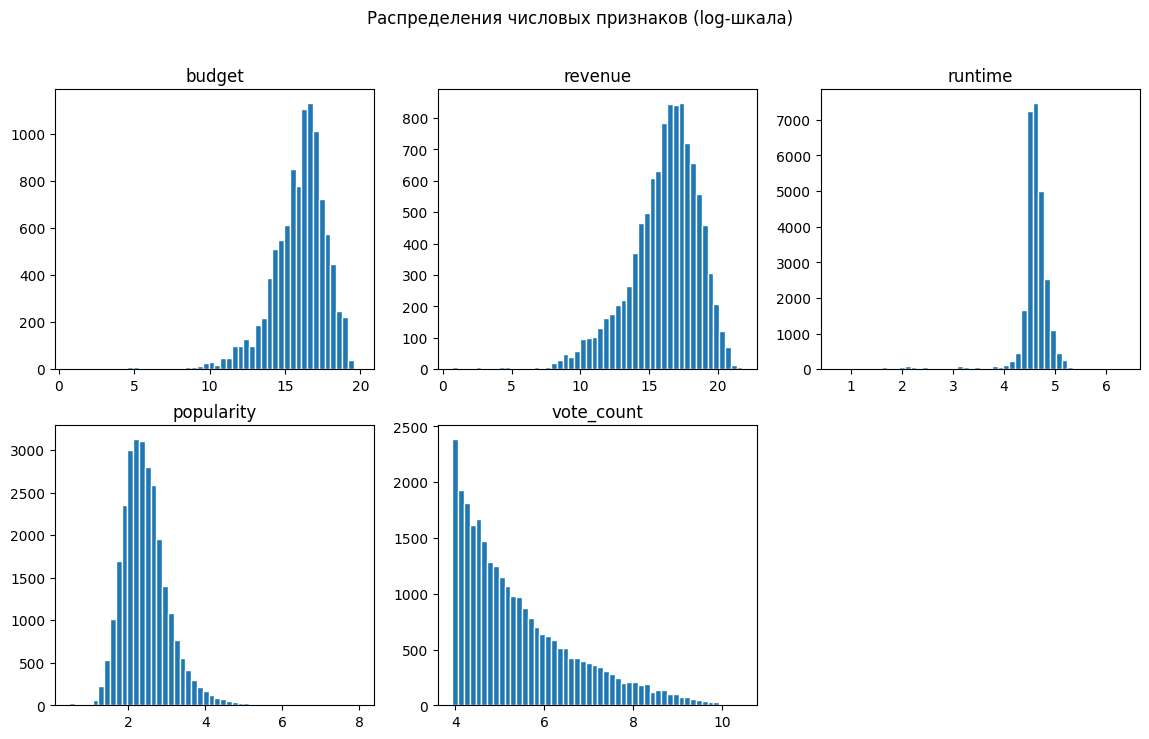

In [152]:
numeric_features = ['budget', 'revenue', 'runtime', 'popularity', 'vote_count']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    data = df_clean.loc[df_clean[col] > 0, col]
    axes[i].hist(np.log1p(data), bins=50, edgecolor='white')
    axes[i].set_title(col)

axes[-1].axis('off')
plt.suptitle('Распределения числовых признаков (log-шкала)')
plt.savefig('../data/processed/eda_numeric_distributions.png')
plt.show()

Бюджет и выручка после логарифмирования показывают близкое к нормальному распределение, но слева находится много фильмов с нулевым или незаполненным бюджетом/сборами. Или просто низкими. Нужно будет решить, что делать с этими строками. Нулевые и незаполненные думаю можно спокойно дропать. Заполнение медианой ничего полезного не даст.

У runtime тоже нормальное распределение. Большинство фильмов длятся в районе log(4,5). Если без логарифма, то это примерно 90 минут. Стандарт. Логарифмировать на самом деле даже не обязательно.

vote_count мы рассмотрели ранее. popularity в принципе тоже показывает экспоненциальный спад, справа тоже есть хвост. Это означает, что без логарифмирования там будут экстремальные выбросы.

Теперь посмотрим насколько разные признаки коррелируют с рейтингом

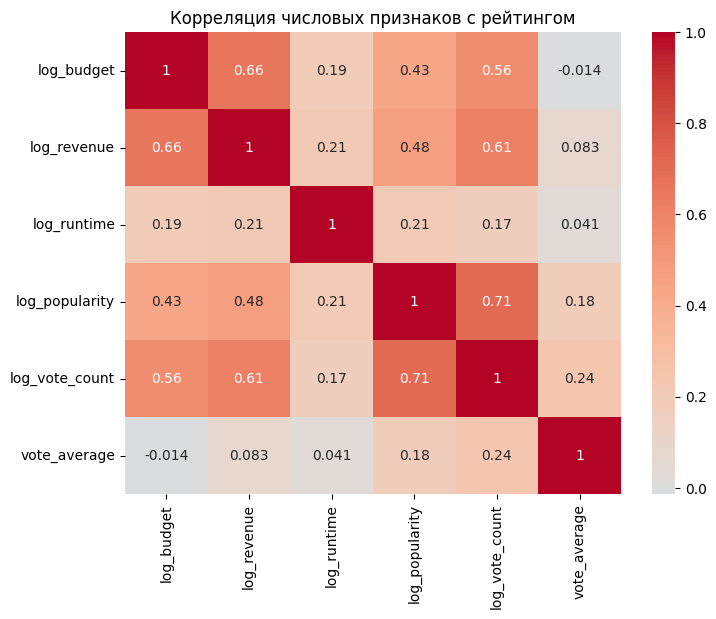

In [153]:
corr_features = numeric_features + ['vote_average']
corr_data = df_clean[corr_features].copy()
for col in numeric_features:
    corr_data[f'log_{col}'] = np.log1p(corr_data[col].clip(lower=0))
log_cols = [f'log_{c}' for c in numeric_features] + ['vote_average']
corr_matrix = corr_data[log_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
ax.set_title('Корреляция числовых признаков с рейтингом')
plt.savefig('../data/processed/eda_correlation.png')
plt.show()

Корреляция всех числовых признаков с vote_average крайне слабая: максимум у log_vote_count (0.24) и log_popularity (0.18), остальные практически на нуле. log_budget показывает даже слабую отрицательную корреляцию (-0.014), то есть бюджет линейно вообще не связан с рейтингом. Числовые признаки сами по себе слабо предсказывают рейтинг. В рамках решения табличной задачи придется улавливать нелинейные зависимости, и это как раз то в чём нейросети сильнее линейных моделей. Плюс теперь мы можем обосновать выбор именно нейросети, а не линейной регрессии.

При этом между собой признаки коррелируют сильно: log_budget и log_revenue (0.66), log_popularity и log_vote_count (0.71). Имеется мультиколлинеарность.

## 6. Рейтинг по годам

/var/folders/mf/gpk354fs7md1m_w2r26tz7400000gn/T/ipykernel_21025/1783788942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['year'] = pd.to_datetime(df_clean['release_date']).dt.year


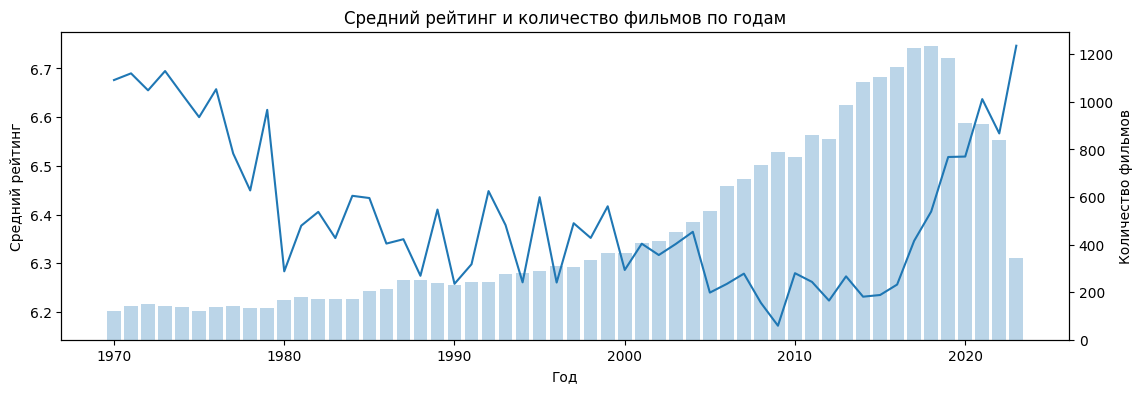

In [154]:
df_clean['year'] = pd.to_datetime(df_clean['release_date']).dt.year
yearly = (
    df_clean[df_clean['year'].between(1970, 2024)]
    .groupby('year')
    .agg(
        avg_rating=('vote_average', 'mean'),
        n_movies=('vote_average', 'count')
    )
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.set_xlabel('Год')
ax1.set_ylabel('Средний рейтинг')
ax2.set_ylabel('Количество фильмов')
ax1.set_title('Средний рейтинг и количество фильмов по годам')
ax1.plot(yearly['year'], yearly['avg_rating'])
ax2.bar(yearly['year'], yearly['n_movies'], alpha=0.3)
plt.savefig('../data/processed/eda_rating_by_year.png')
plt.show()

До 2010 года средний рейтинг держится в диапазоне 6.2–6.5 с заметной волатильностью, особенно в 70-е и 80-е, когда количество фильмов было небольшим и каждый отдельный фильм сильно влиял на среднее. После 2010 наблюдается устойчивый рост рейтинга вплоть до резкого скачка в 2022–2024, где средний рейтинг достиг 6.7 и выше.

Скорее всего, это не значит, что современные фильмы лучше. Скорее всего тут две причины. Первая - у старых фильмов больше времени накопить оценки, и со временем выживают только те, которые люди помнят и любят. Второй — у очень новых фильмов (2022–2024) ещё мало оценок, несмотря на наш фильтр vote_count >= 50, видимо, первые зрители оказываются более лояльны.

## 7. Манипуляции с жанрами

Соберем датасет конкретно под первую задачу, включим в него только нужные столбцы

In [155]:
tabular_cols = [
    'id', 'title', 'year', 'runtime', 'budget', 'revenue',
    'popularity', 'vote_count', 'vote_average', 'is_high_rated',
    'primary_genre', 'genres_list', 'n_genres',
    'original_language', 'poster_path', 'production_companies', 'production_countries'
]

df_tabular = df_clean[tabular_cols]

df_tabular.to_csv('../data/processed/tmdb_clean.csv', index=False)

len(df_tabular)

27943

27943 фильмов мы сохранили

## 8. Подготовка датасета для задачи на неструктурированных данных

Далее проблема. В чем она заключается, среди вот этих 27943 фильмов, жанры распределены неравномерно. Каких-то много, каких-то мало. При этом для обучения, фильмов в рамках какого-либо жанра должно быть ощутимое количество. Сейчас покажем, что имеем в виду

In [156]:
top_genres = genre_counts.head(10).index.tolist()
top_genres

['Drama',
 'Comedy',
 'Thriller',
 'Action',
 'Romance',
 'Horror',
 'Crime',
 'Adventure',
 'Family',
 'Science Fiction']

Это топ-10 жанров списком

In [157]:
df_cv = df_clean[df_clean['primary_genre'].isin(top_genres)].copy()
len(df_cv)

23614

Оставили только эти самые популярные жанры, вот столько строк осталось. Почему 10 - это число было выбрано уже после следующей таблицы

In [158]:
df_cv['primary_genre'].value_counts()

primary_genre
Drama              6403
Comedy             6222
Action             2997
Horror             2392
Thriller           1299
Crime              1140
Adventure          1094
Romance             864
Science Fiction     608
Family              595
Name: count, dtype: int64

В общем, 10 было выбрано для наглядности. Хотя бы 1000 фильмов есть только в топ-7 жанрах

И среди оставшихся вот такое количество фильмов, где главный жанр входит в топ самых популярных

Скачаем по 1000 постеров для топ-7 категорий, где эти 1000 постеров вообще есть

In [159]:
top_genres = ['Drama', 'Comedy', 'Action', 'Horror', 'Thriller', 'Crime', 'Adventure']
df_cv_balanced = (df_clean[df_clean["primary_genre"].isin(top_genres)].groupby("primary_genre").sample(n=1000, replace=False, random_state=42))

df_cv_balanced.to_csv('../data/processed/tmdb_clean1.csv', index=False)

## 8. Ключевая бизнес-гипотеза: постеры и рейтинг

In [160]:
downloaded_posters = set(f.stem for f in Path('../data/raw/posters/downloaded').glob('*.jpg'))
if 'id' in df_clean.columns:
    df_clean['poster_downloaded'] = df_clean['id'].astype(str).isin(downloaded_posters)
len(downloaded_posters)

/var/folders/mf/gpk354fs7md1m_w2r26tz7400000gn/T/ipykernel_21025/2924350713.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['poster_downloaded'] = df_clean['id'].astype(str).isin(downloaded_posters)


9685

По факту вот столько постеров мы имеем в папке

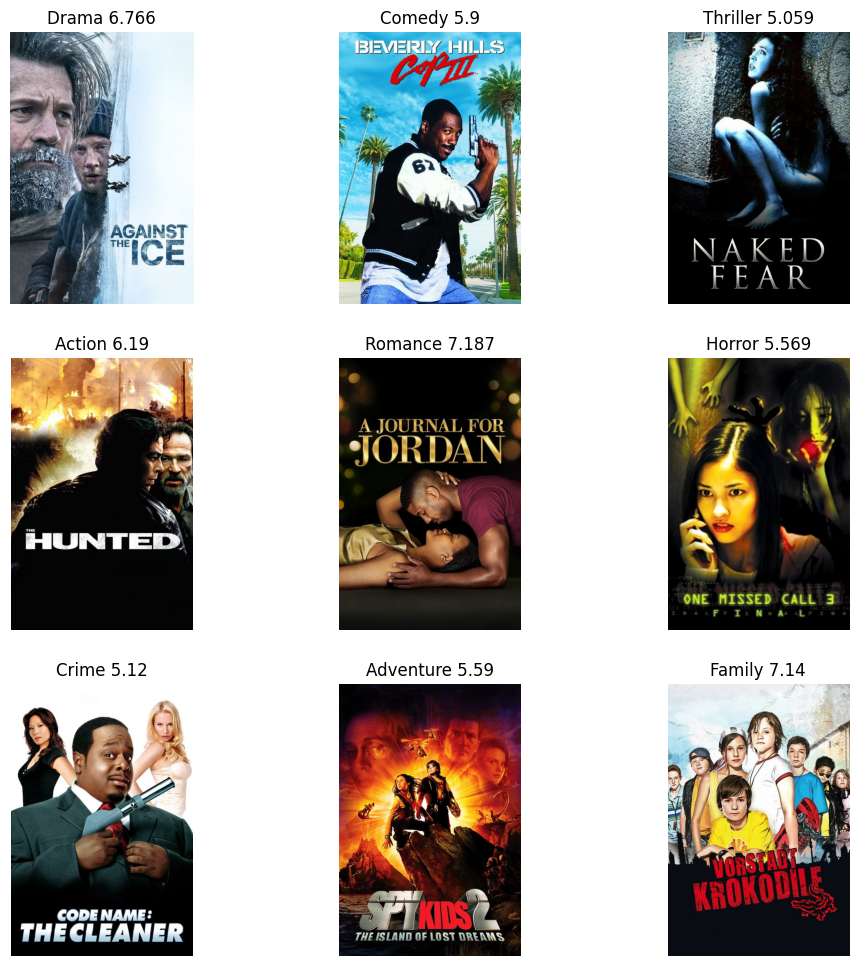

In [161]:
genres = df_clean.explode('genres_list')
top_genres = genre_counts.head(9).index
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for i, genre in enumerate(top_genres):
    movie = genres[
        (genres['genres_list'] == genre) &
        (genres['poster_downloaded'])
    ].sample(1).iloc[0]
    axes[i].imshow(
        mpimg.imread(Path('../data/raw/posters/downloaded') / f"{movie['id']}.jpg")
    )
    axes[i].set_title(genre + " " + str(movie["vote_average"]))
    axes[i].axis('off')
plt.show()